In [1]:
library(msigdbr)
library(cluster)
library(data.table)
library(circlize)
library(ComplexHeatmap)
library(clusterProfiler)

source("/mnt/lareaulab/reliscu/code/fisher_test.R")

circlize version 0.4.18
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(library(circlize))


Loading required package: grid

ComplexHeatmap version 2.26.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps in

In [2]:
gs_GO <- msigdbr(collection="C5") # , subcollection="GO:BP")
gs_GO_list <- tapply(gs_GO$gene_symbol, INDEX=gs_GO$gs_name, FUN=list)
gs_GO_list <- gs_GO_list[grep("^HP", names(gs_GO_list), invert=TRUE)]
gs_GO_list <- gs_GO_list[grep("^GOCC", names(gs_GO_list), invert=TRUE)]
min_set_size <- 5
max_set_size <- 200

set_sizes <- lengths(gs_GO_list)
mask <- (set_sizes < max_set_size) & (set_sizes > min_set_size)
gs_GO_list <- gs_GO_list[mask]

print(length(gs_GO_list))

[1] 7825


In [3]:
psi_corr_df <- fread("data/ctype_exons/exon_PSI_abundance_correlations.csv", data.table=FALSE)
psi_fdr_df <- fread("data/ctype_exons/exon_PSI_abundance_correlation_FDRs.csv", data.table=FALSE)

## Major cell classes

In [ ]:
ct_inds <- c(5, 8:ncol(psi_corr_df))
print(colnames(psi_corr_df)[ct_inds])

rows_to_keep <- apply(psi_fdr_df[,ct_inds], 1, function(row) {
    if(any(row == 0) & var(row) > 0) {
        return(TRUE)
    } else {
        return(FALSE)
    }
})
print(sum(rows_to_keep))
psi_corr_filtered <- psi_corr_df[rows_to_keep, ] 

rownames(psi_corr_filtered) <- psi_corr_df[rows_to_keep, 1, drop=TRUE]
corr_mat <- cor(t(psi_corr_filtered[, ct_inds]))

d <- as.dist(1 - corr_mat)
hc <- hclust(d, method="ward.D2")

[1] "All Neuronal" "Oligo"        "OPC"          "Astro"        "Micro/PVM"   
[6] "VLMC"         "Endo"         "Peri"        


[1] 12685


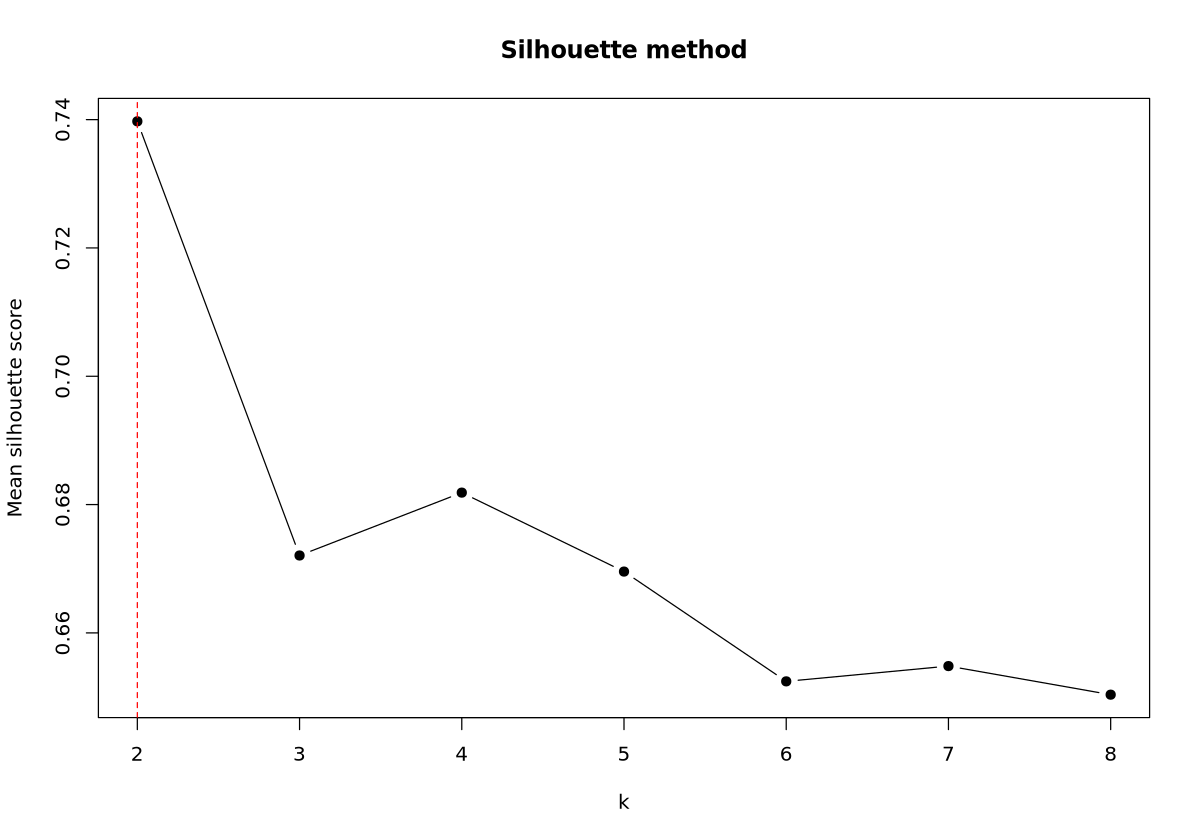

In [281]:
k_range <- 2:8

sil_scores <- sapply(k_range, function(k) {
  clusters <- cutree(hc, k = k)
  mean(silhouette(clusters, d)[, 3])
})

options(repr.plot.width=10, repr.plot.height=7)

plot(k_range, sil_scores, type = "b", pch = 19,
     xlab = "k", ylab = "Mean silhouette score",
     main = "Silhouette method")
abline(v = k_range[which.max(sil_scores)], lty = 2, col = "red")

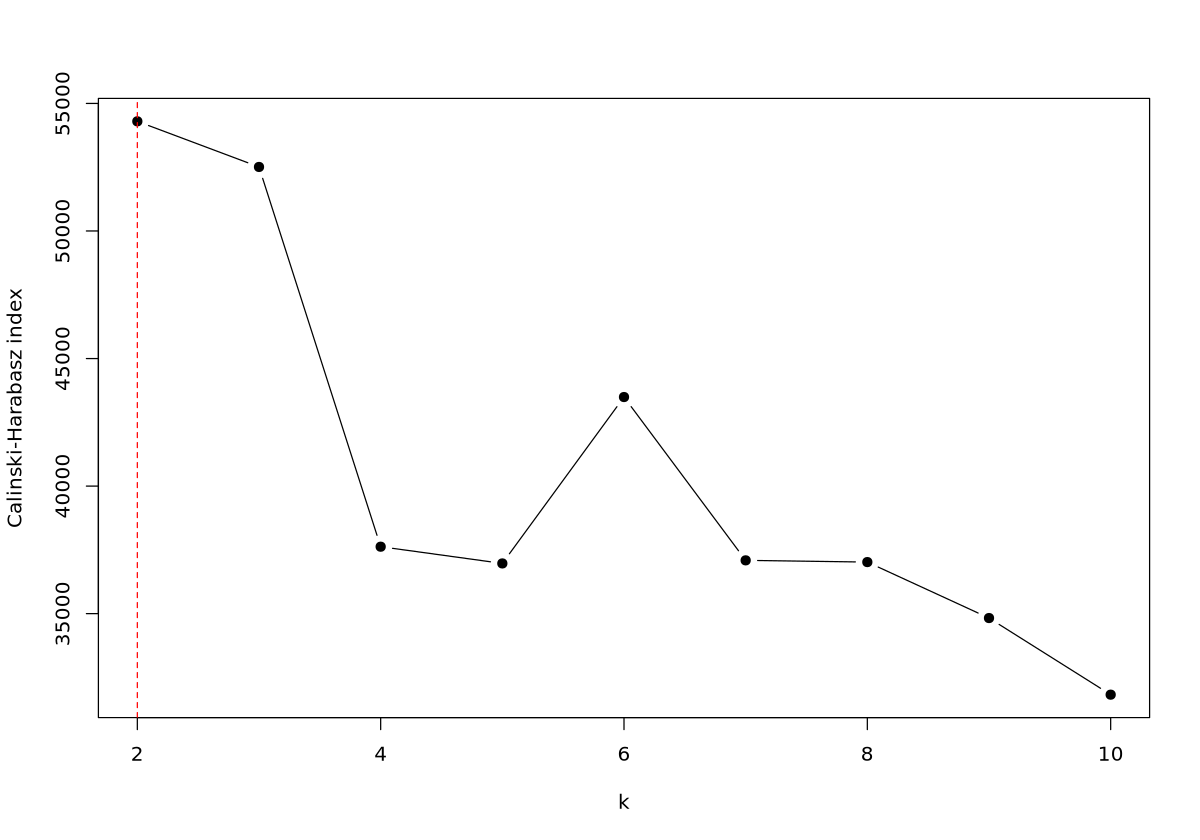

In [287]:
ch_score_fast <- function(mat, clusters) {
  k          <- length(unique(clusters))
  n          <- nrow(mat)
  grand_mean <- colMeans(mat)
  
  # precompute cluster means once
  cluster_means <- lapply(unique(clusters), function(cl) colMeans(mat[clusters == cl, , drop = FALSE]))
  names(cluster_means) <- unique(clusters)
  cluster_sizes <- table(clusters)
  
  bss <- sum(mapply(function(cl_mean, cl_size) {
    cl_size * sum((cl_mean - grand_mean)^2)
  }, cluster_means, cluster_sizes))
  
  wss <- sum(mapply(function(cl, cl_mean) {
    sub <- mat[clusters == cl, , drop = FALSE]
    sum(sweep(sub, 2, cl_mean)^2)  # sweep is much faster than apply row-by-row
  }, unique(clusters), cluster_means))
  
  (bss / (k - 1)) / (wss / (n - k))
}

ch_scores <- sapply(2:10, function(k) ch_score_fast(corr_mat, cutree(hc, k)))

plot(2:10, ch_scores, type = "b", pch = 19,
     xlab = "k", ylab = "Calinski-Harabasz index")
abline(v = which.max(ch_scores) + 1, lty = 2, col = "red")

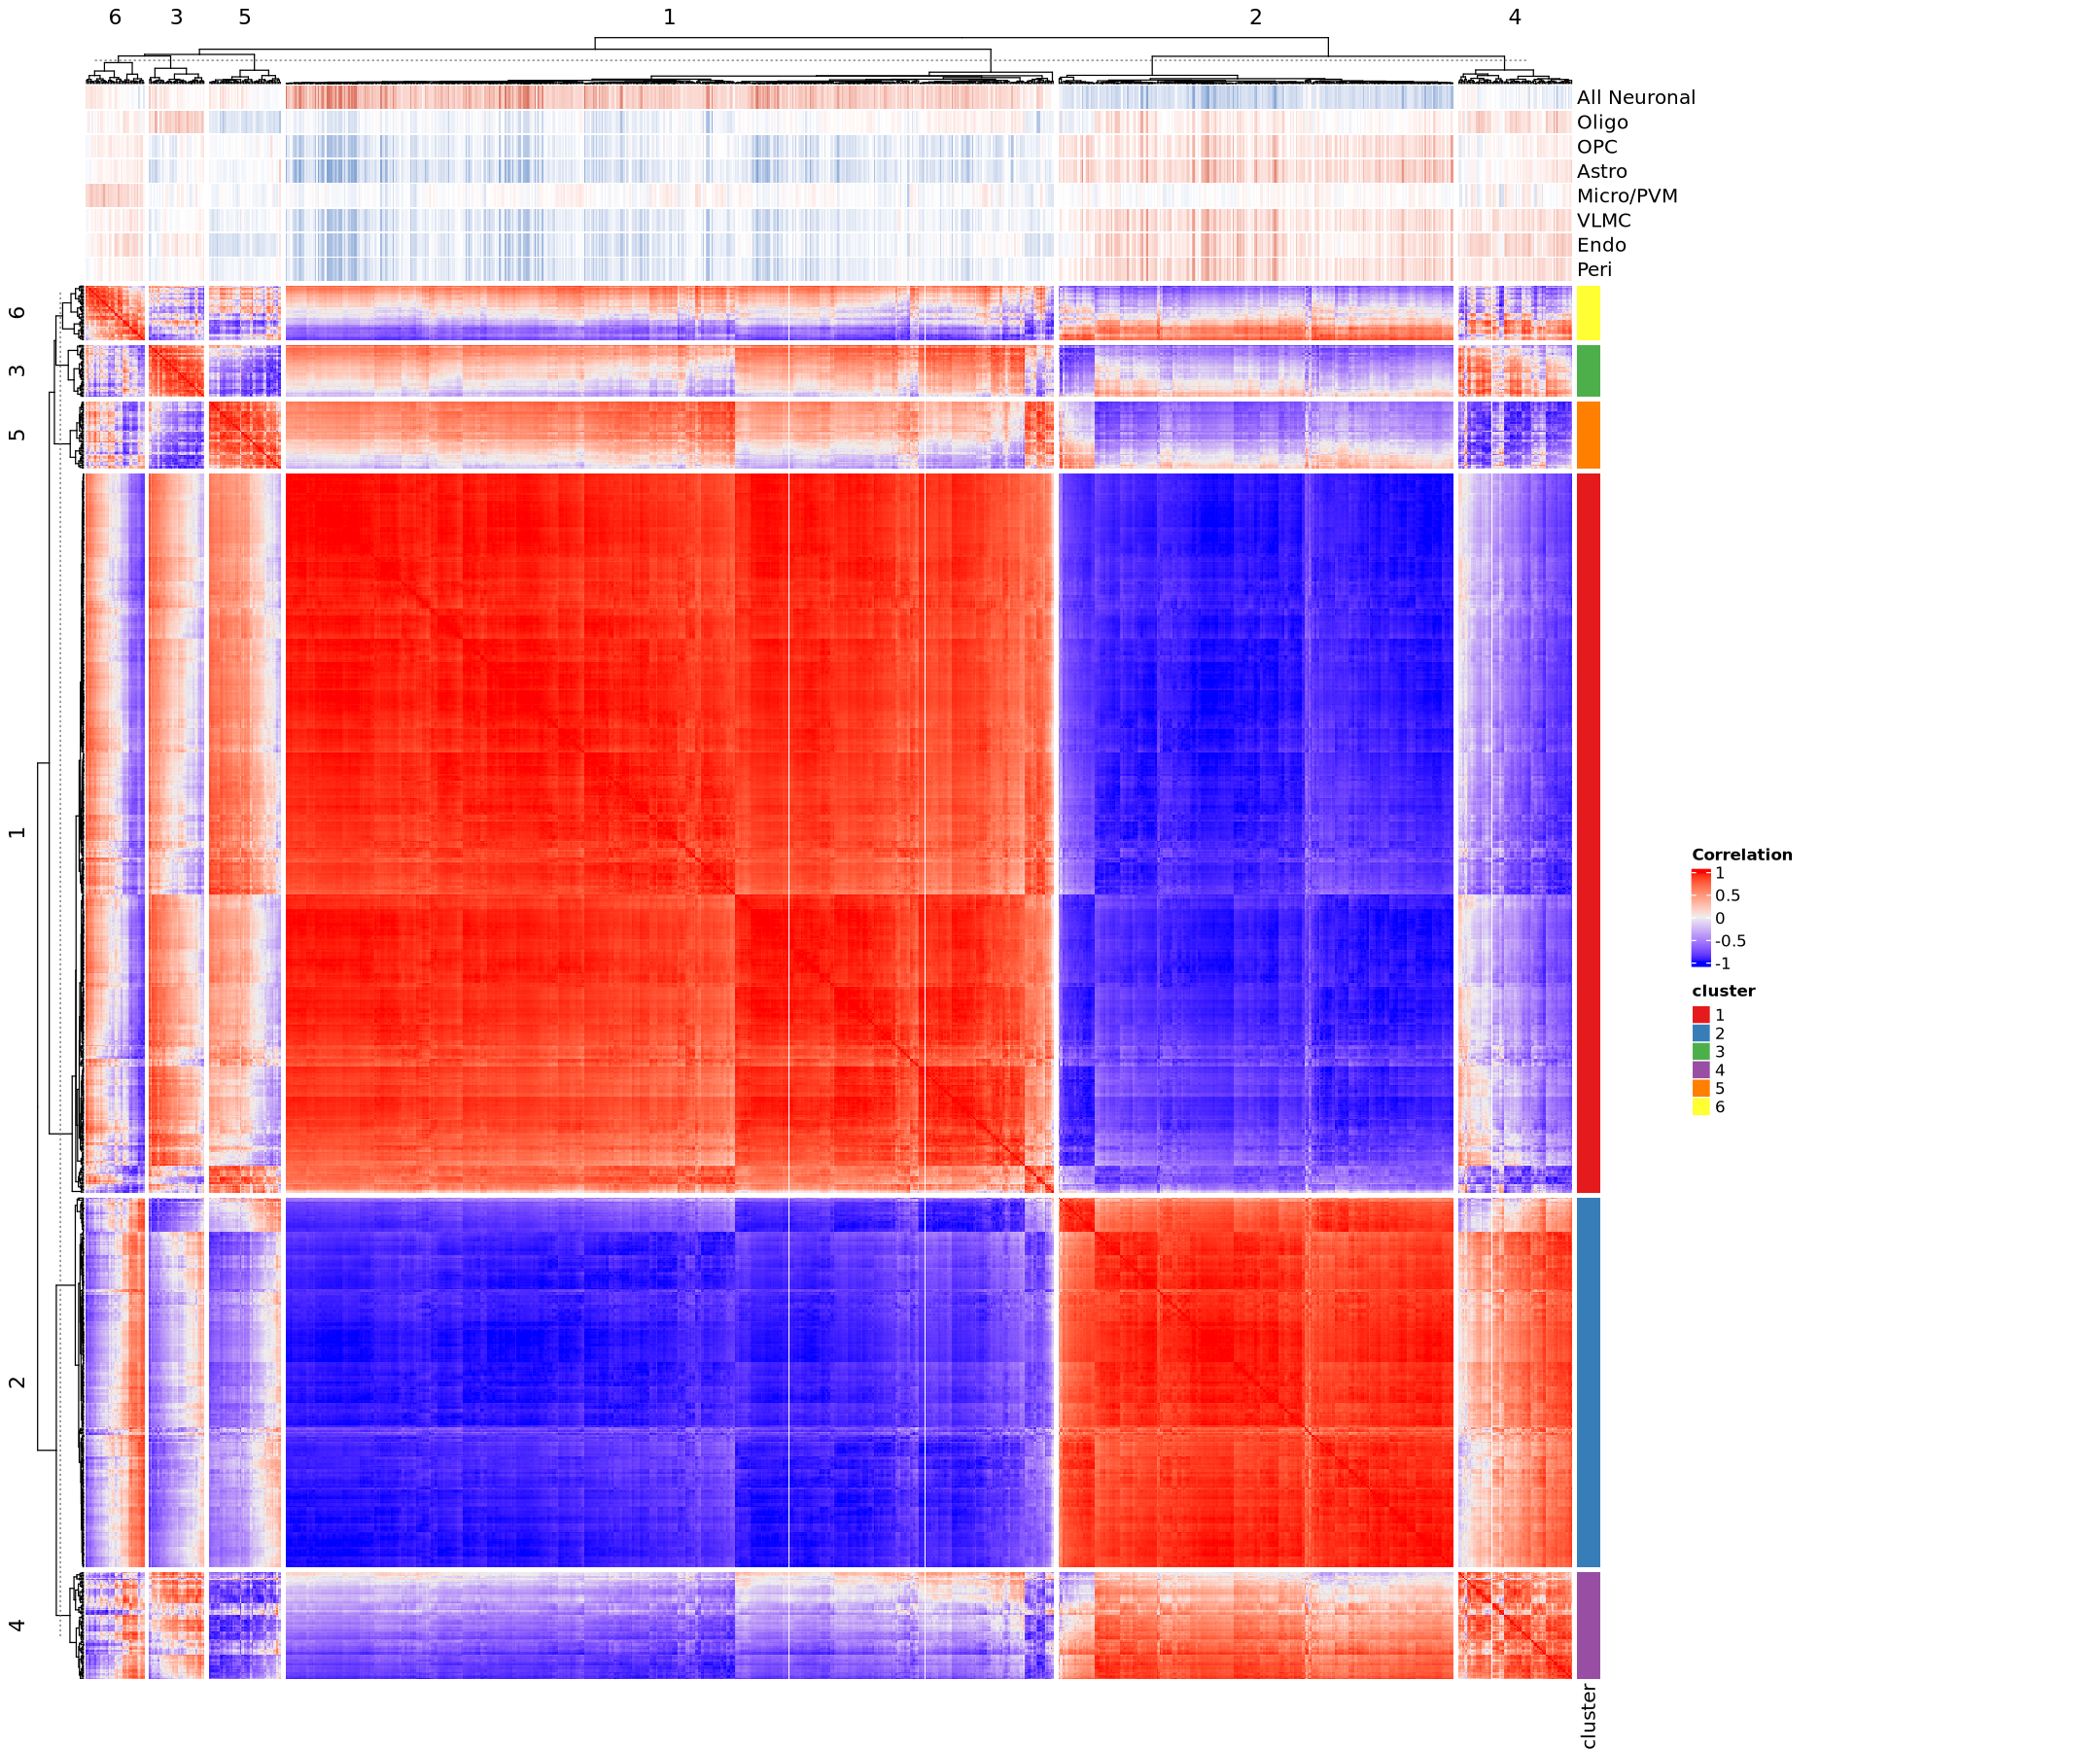

In [295]:
k  <- 6
clusters <- cutree(hc, k = k)
background <- psi_corr_filtered$Gene
cluster_genes <- tapply(background, clusters, list)

# Subset samples for efficient plotting

set.seed(1)
sample_idx_subset <- sample(1:ncol(corr_mat), size=1000)
ctype_corrs <- psi_corr_filtered[sample_idx_subset, ct_inds]
clusters_subset <- clusters[sample_idx_subset]

col_anno <- do.call(HeatmapAnnotation, c(
  ctype_corrs,
  list(col = lapply(ctype_corrs, function(x) 
    circlize::colorRamp2(c(-1, 0, 1), c("#3A7EC0", "white", "#C1392B"))
  )),
  show_legend = FALSE
))

row_anno <- rowAnnotation(
  cluster = as.character(clusters_subset),
  col = list(cluster = setNames(
    RColorBrewer::brewer.pal(k, "Set1"),
    as.character(1:k)
  ))
)

options(repr.plot.width=18, repr.plot.height=15)

ht <- Heatmap(
  corr_mat[sample_idx_subset, sample_idx_subset],
  name = "Correlation",
  top_annotation  = col_anno,
  right_annotation = row_anno,
  cluster_rows = TRUE, #hc,
  cluster_columns = TRUE,# hc,
  show_row_names = FALSE,      
  show_column_names = FALSE,
  row_split = clusters_subset,   
  column_split = clusters_subset,
  border = FALSE
)

draw(ht, padding = unit(c(2, 2, 2, 70), "mm"))

In [302]:
i <- 2

enrich_res_list <- lapply(unlist(lapply(gs_GO_list, function(set) {
    fisher_test(set, unique(cluster_genes[[i]]), all=unique(background))
})), c)
    
enrich_df <- reshape2::melt(enrich_res_list)
# enrich_df$Qval <- qvalue(enrich_df$Pval)$qvalue
enrich_df %>% arrange(value) %>% head(20)

,value,L1
,<dbl>,<chr>
1,3.382754e-05,GOBP_NUCLEOSOME_ORGANIZATION
2,5.960105e-04,GOBP_VESICLE_BUDDING_FROM_MEMBRANE
3,7.461950e-04,GOBP_AUTOPHAGOSOME_ORGANIZATION
4,9.341873e-04,GOBP_FATTY_ACID_BETA_OXIDATION
5,9.546359e-04,GOBP_MRNA_TRANSPORT
6,1.019921e-03,GOMF_LIGASE_ACTIVITY
7,1.043925e-03,GOBP_PROTEIN_N_LINKED_GLYCOSYLATION
8,1.136807e-03,GOBP_ESTABLISHMENT_OF_RNA_LOCALIZATION
9,1.167969e-03,GOBP_RETROGRADE_VESICLE_MEDIATED_TRANSPORT_GOLGI_TO_ENDOPLASMIC_RETICULUM


## Neurons only

In [4]:
ct_inds <- 3:7
print(colnames(psi_corr_df)[ct_inds])

rows_to_keep <- apply(psi_fdr_df[,ct_inds], 1, function(row) {
    if(any(row == 0) & var(row) > 0) {
        return(TRUE)
    } else {
        return(FALSE)
    }
})
print(sum(rows_to_keep))
psi_corr_filtered <- psi_corr_df[rows_to_keep, ]  # after rows_to_keep filter

rownames(psi_corr_filtered) <- psi_corr_df[rows_to_keep, 1, drop=TRUE]
corr_mat <- cor(t(psi_corr_filtered[, ct_inds]))

d <- as.dist(1 - corr_mat)
hc <- hclust(d, method="ward.D2")

[1] "CGE Class"                 "All GABAergic"            
[3] "All Neuronal"              "Upper layer glutamatergic"
[5] "Deep layer glutamatergic" 


[1] 9335


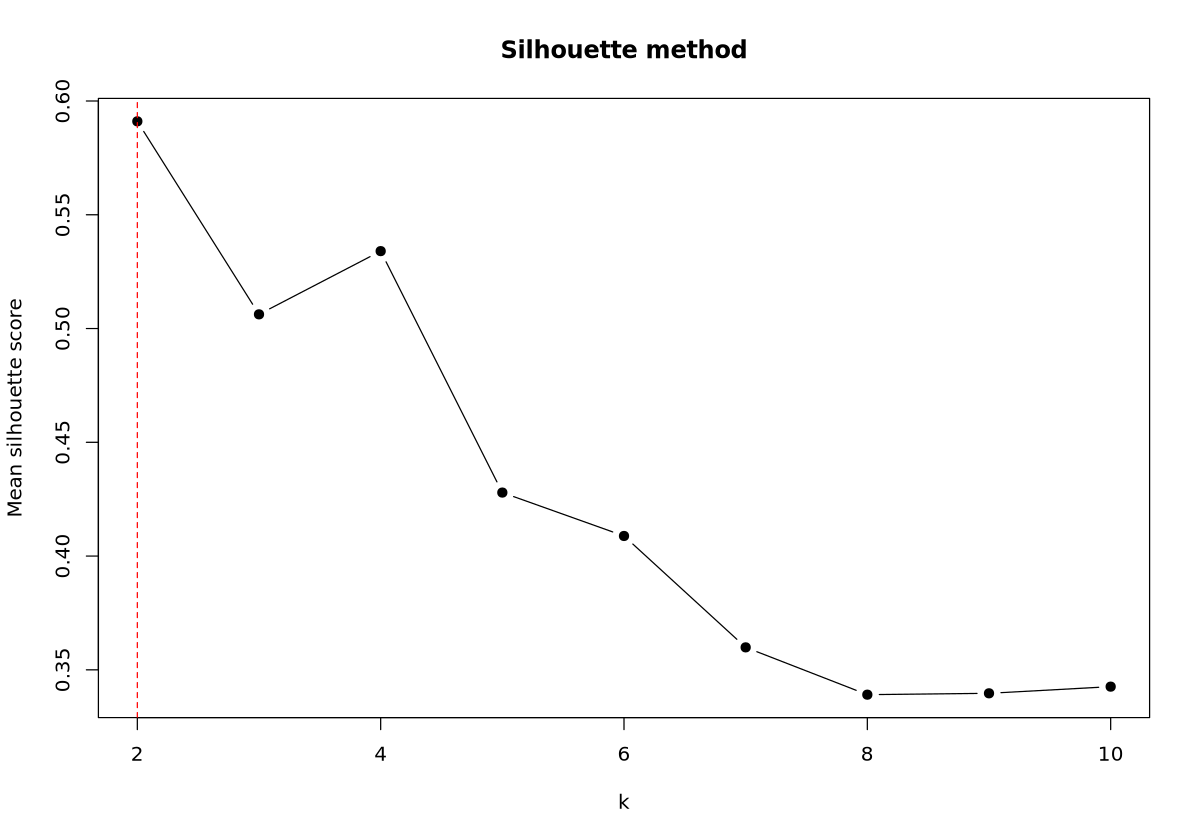

In [270]:
k_range <- 2:10

sil_scores <- sapply(k_range, function(k) {
  clusters <- cutree(hc, k = k)
  mean(silhouette(clusters, d)[, 3])
})

options(repr.plot.width=10, repr.plot.height=7)

plot(k_range, sil_scores, type = "b", pch = 19,
     xlab = "k", ylab = "Mean silhouette score",
     main = "Silhouette method")
abline(v = k_range[which.max(sil_scores)], lty = 2, col = "red")

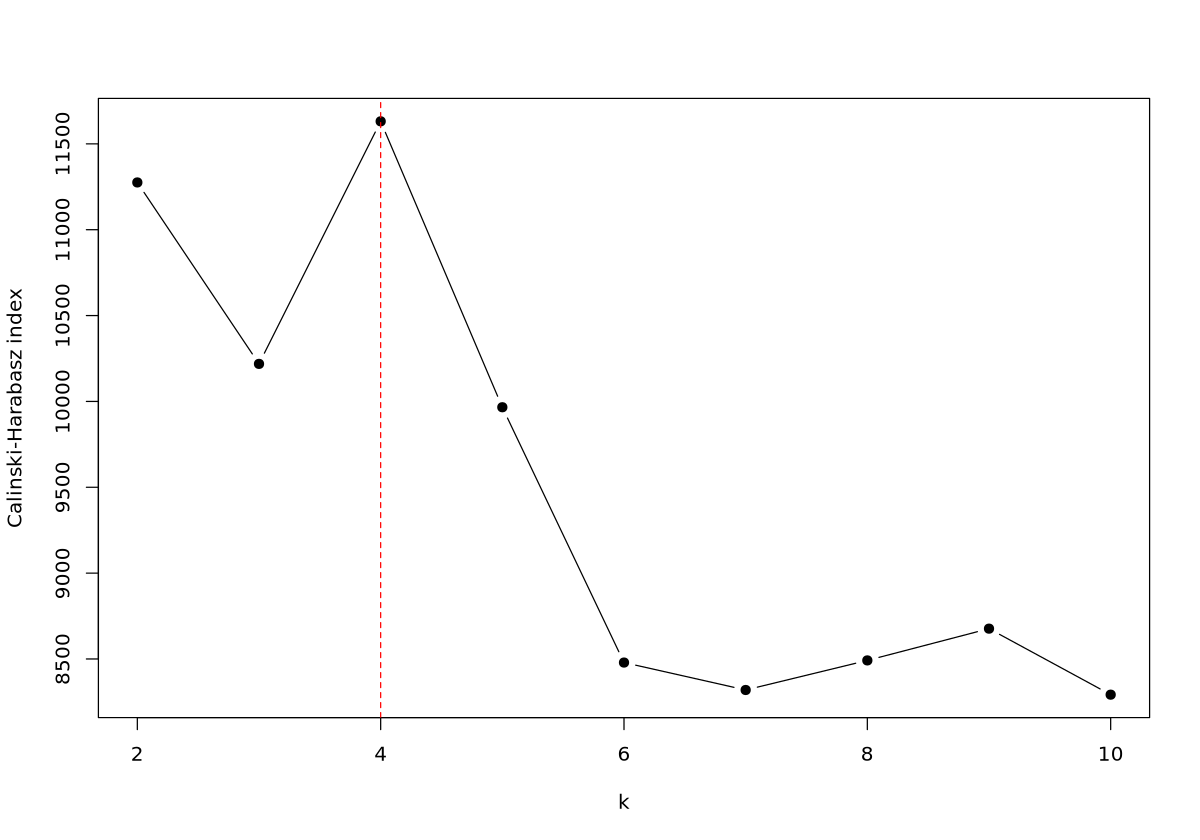

In [285]:
ch_scores <- sapply(2:10, function(k) ch_score_fast(corr_mat, cutree(hc, k)))

plot(2:10, ch_scores, type = "b", pch = 19,
     xlab = "k", ylab = "Calinski-Harabasz index")
abline(v = which.max(ch_scores) + 1, lty = 2, col = "red")

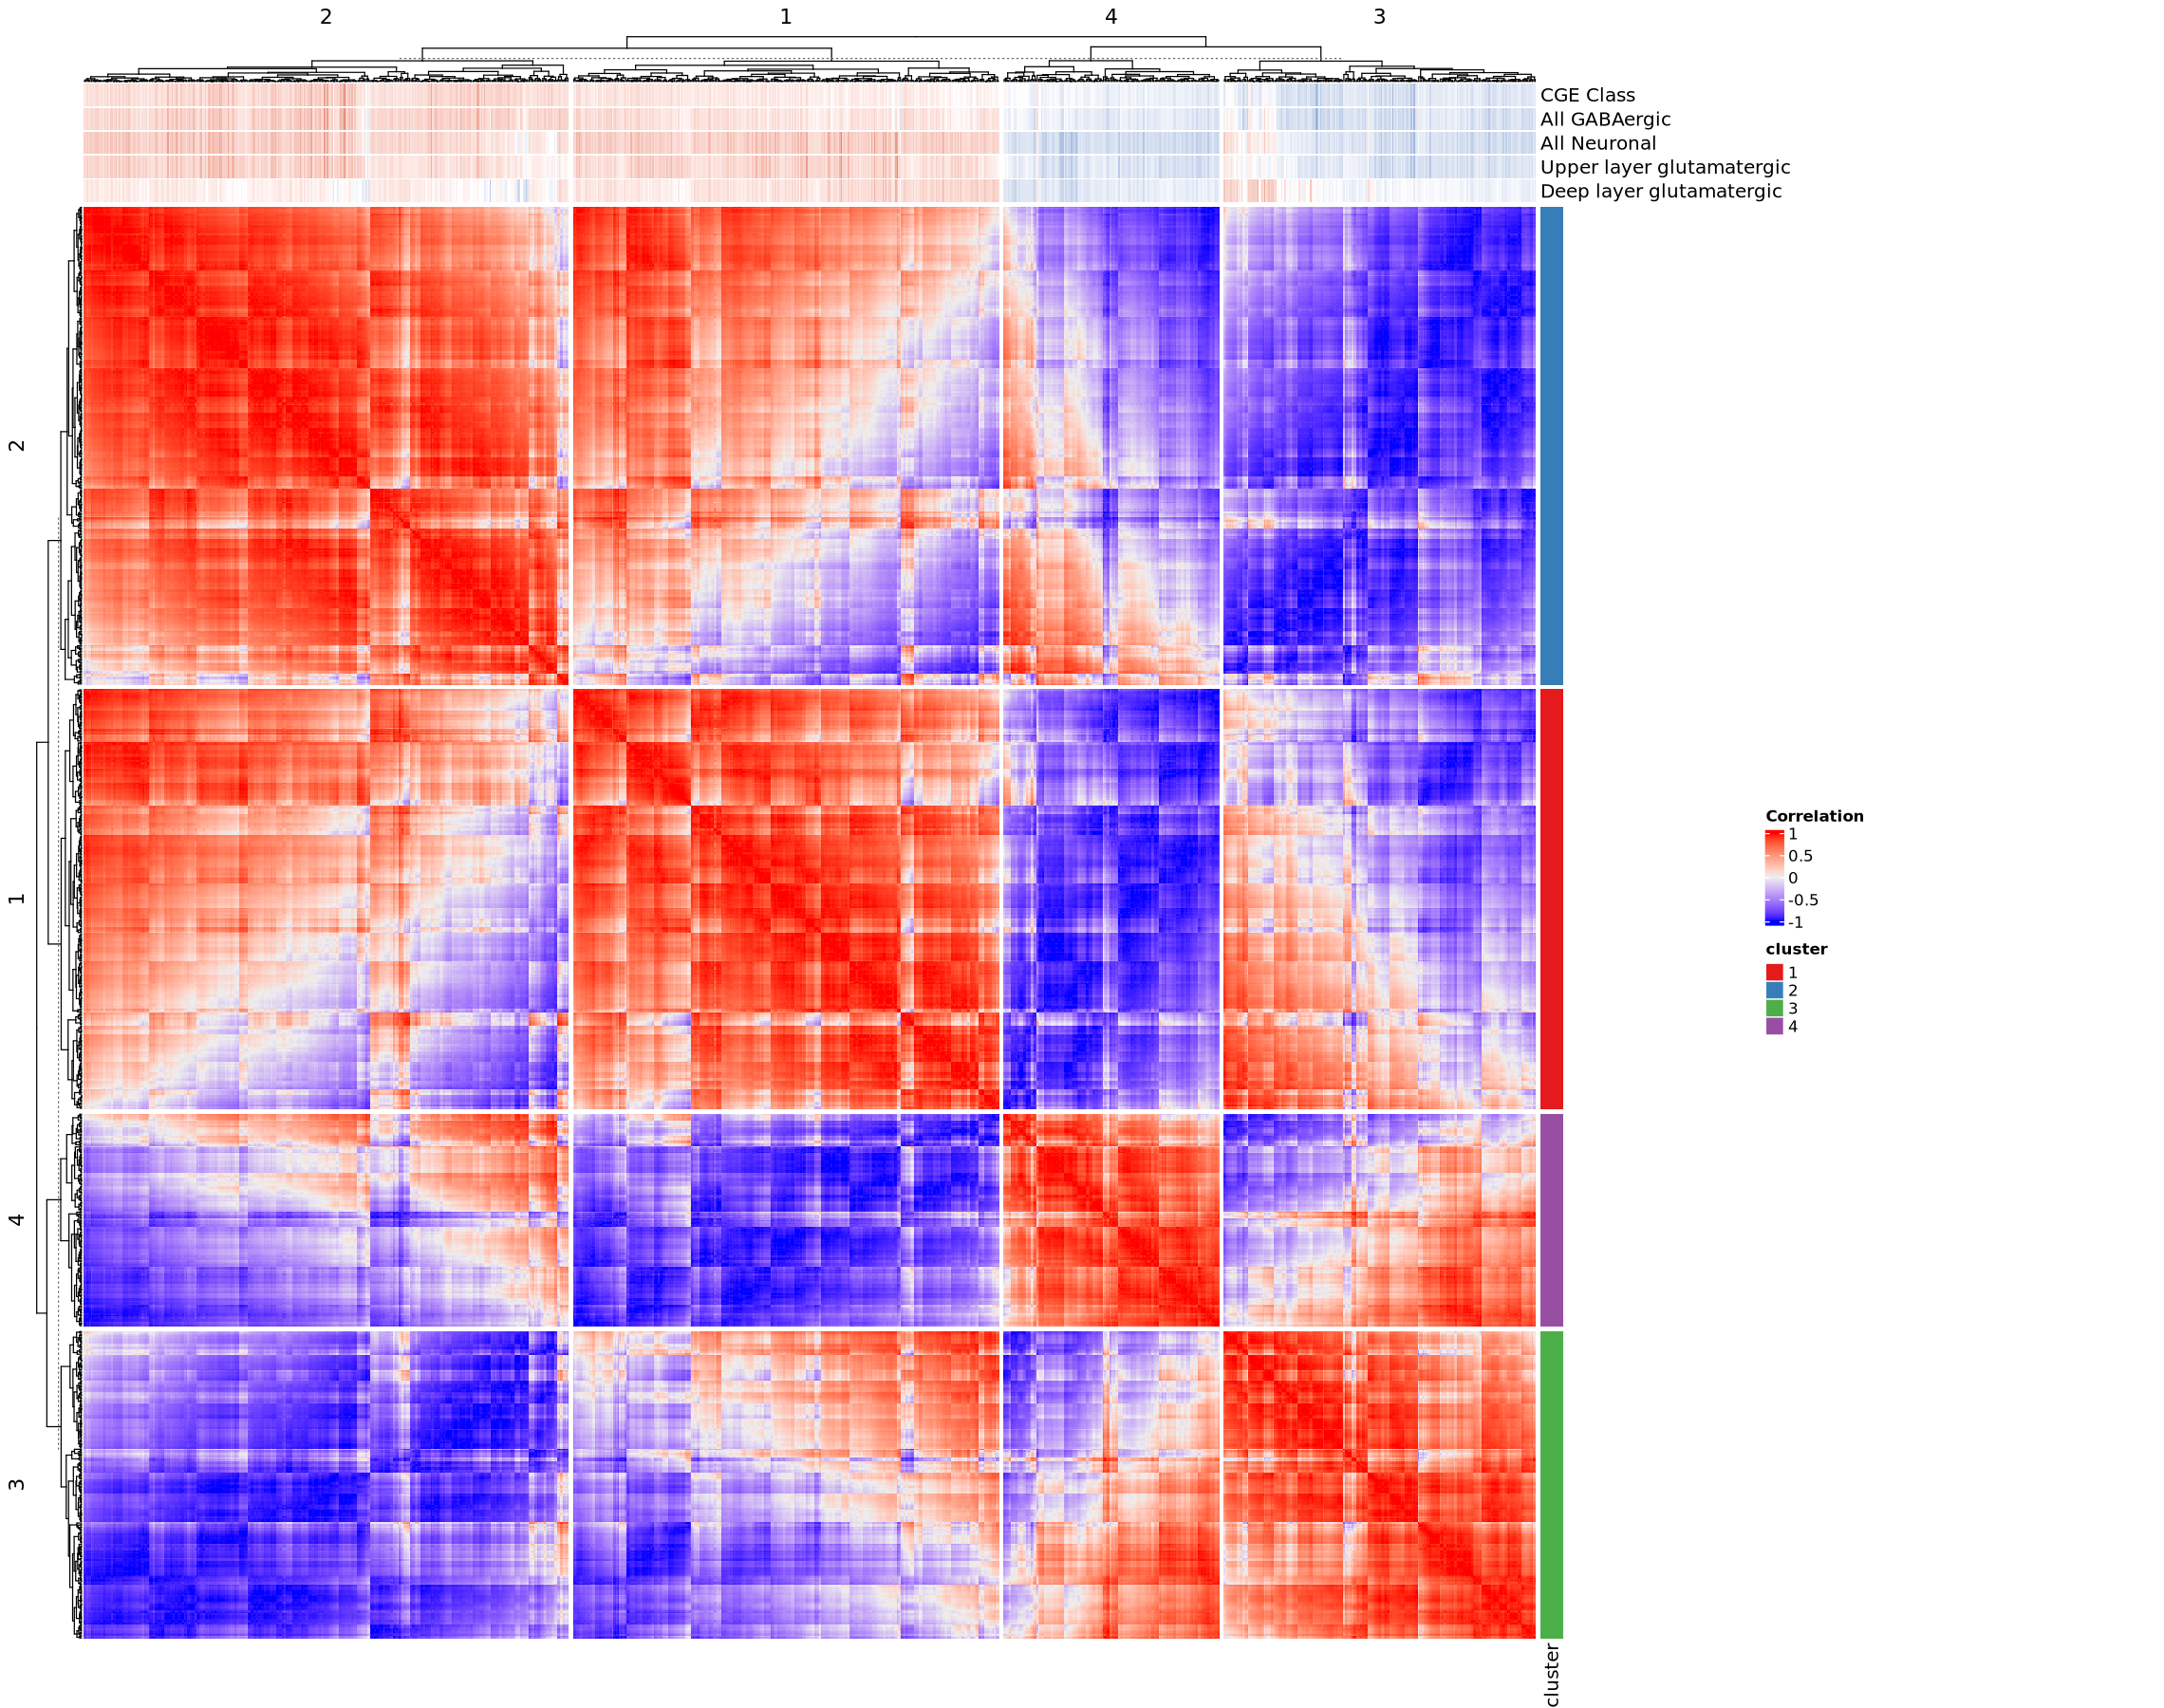

In [ ]:
k <- 4
clusters <- cutree(hc, k = k)
background <- psi_corr_filtered$Gene
cluster_genes <- tapply(background, clusters, list)

# Subset samples for efficient plotting

set.seed(2)
sample_idx_subset <- sample(1:ncol(corr_mat), size=1000)
ctype_corrs <- psi_corr_filtered[sample_idx_subset, ct_inds]
clusters_subset <- clusters[sample_idx_subset]

col_anno <- do.call(HeatmapAnnotation, c(
  ctype_corrs,
  list(col = lapply(ctype_corrs, function(x) 
    circlize::colorRamp2(c(-1, 0, 1), c("#3A7EC0", "white", "#C1392B"))
  )),
  show_legend = FALSE
))

row_anno <- rowAnnotation(
  cluster = as.character(clusters_subset),
  col = list(cluster = setNames(
    RColorBrewer::brewer.pal(k, "Set1"),
    as.character(1:k)
  ))
)

options(repr.plot.width=19, repr.plot.height=15)

ht <- Heatmap(
  corr_mat[sample_idx_subset, sample_idx_subset],
  name = "Correlation",
  top_annotation = col_anno,
  right_annotation = row_anno,
#   cluster_rows = TRUE, #hc,
#   cluster_columns = TRUE, # hc,
  show_row_names = FALSE,      
  show_column_names = FALSE,
  row_split = clusters_subset,   
  column_split = clusters_subset,
  border = FALSE
)

draw(ht, padding = unit(c(2, 2, 2, 70), "mm"))

In [248]:
# corr_mat rows correspond to rows_to_keep rows of psi_corr_df
# so we need to track the original psi_corr_df indices through both subsets
psi_corr_filtered <- psi_corr_df[rows_to_keep, ]  # after rows_to_keep filter

# sample_idx subsets corr_mat (which = rows_to_keep rows)
# sample_idx_subset then subsets that
final_idx <- sample_idx[sample_idx_subset]  # map back to psi_corr_filtered indices

ctype_corrs <- psi_corr_filtered[final_idx, ct_inds]

# now check
identical(rownames(ctype_corrs), colnames(corr_mat_subset[sample_idx_subset, sample_idx_subset]))

[1] TRUE

In [245]:
# check that annotation rows match heatmap columns
identical(rownames(ctype_corrs), colnames(corr_mat_subset[sample_idx_subset, sample_idx_subset]))

[1] FALSE

In [ ]:
corr_mat_subset[clusters == 1, clusters == 2]

In [240]:
cor(t(psi_corr_df[rows_to_keep,][clusters == 3, 3:ncol(psi_corr_df)]))

,ENSG00000228794_other_19,ENSG00000131584_ProteinCoding_1,ENSG00000215915_ProteinCoding_1,ENSG00000248333_ProteinCoding_2,ENSG00000008130_ProteinCoding_3,ENSG00000162585_other_1,ENSG00000069424_ProteinCoding_3,ENSG00000116254_ProteinCoding_1,ENSG00000171735_NMD_3,ENSG00000049246_other_1,⋯,ENSG00000067842_ProteinCoding_4,ENSG00000198910_ProteinCoding_3,ENSG00000147403_ProteinCoding_1,ENSG00000013563_ProteinCoding_2,ENSG00000013563_ProteinCoding_3,ENSG00000102125_ProteinCoding_5,ENSG00000102125_other_1,ENSG00000071553_NMD_2,ENSG00000071553_NMD_3,ENSG00000071553_ProteinCoding_1
ENSG00000228794_other_19,1.000000000,0.96640814,0.03774612,0.9731354,0.83549171,0.9769606,0.97373881,0.67452181,0.9194818,-0.39514100,⋯,0.95791721,0.99144220,0.98023937,0.96917086,0.96280198,0.97316238,0.98051754,0.9387010,0.875564225,0.94678801
ENSG00000131584_ProteinCoding_1,0.966408139,1.00000000,-0.02512135,0.9369156,0.71066129,0.9093404,0.91073618,0.65223742,0.8496773,-0.40385314,⋯,0.90812498,0.96715862,0.93292331,0.90619505,0.89480344,0.91013038,0.93036944,0.8793928,0.811181926,0.86658428
ENSG00000215915_ProteinCoding_1,0.037746123,-0.02512135,1.00000000,0.0618758,0.46221180,0.0836399,0.07268882,0.65707318,0.1863710,0.83518058,⋯,0.11544528,0.09521615,0.10359766,0.16972548,0.16216608,0.16241274,0.12881866,0.3477698,0.451584755,0.10314019
ENSG00000248333_ProteinCoding_2,0.973135358,0.93691555,0.06187580,1.0000000,0.82282883,0.9731698,0.92881412,0.59483422,0.9459196,-0.31180091,⋯,0.90295734,0.97633719,0.92700580,0.95943992,0.95321372,0.93318808,0.93912872,0.9239426,0.869985578,0.92659201
ENSG00000008130_ProteinCoding_3,0.835491715,0.71066129,0.46221180,0.8228288,1.00000000,0.8941120,0.88890173,0.79104087,0.8814371,0.01484989,⋯,0.85948930,0.84327961,0.87205536,0.89386984,0.90008211,0.89892758,0.87279878,0.9200478,0.896235680,0.91355649
ENSG00000162585_other_1,0.976960646,0.90934044,0.08363990,0.9731698,0.89411204,1.0000000,0.98003320,0.63842439,0.9611562,-0.32930090,⋯,0.94199342,0.97247994,0.96319888,0.97519557,0.97692450,0.96529347,0.96219876,0.9349299,0.871133207,0.98488976
ENSG00000069424_ProteinCoding_3,0.973738814,0.91073618,0.07268882,0.9288141,0.88890173,0.9800332,1.00000000,0.68752774,0.9086385,-0.37582634,⋯,0.95293572,0.96055775,0.98294884,0.95530600,0.95984176,0.96535547,0.96186765,0.9209541,0.846769317,0.98064529
ENSG00000116254_ProteinCoding_1,0.674521806,0.65223742,0.65707318,0.5948342,0.79104087,0.6384244,0.68752774,1.00000000,0.6280107,0.21646181,⋯,0.73235048,0.69768012,0.73928754,0.70387639,0.68908142,0.74861418,0.74006117,0.8298657,0.851360773,0.64548851
ENSG00000171735_NMD_3,0.919481844,0.84967727,0.18637105,0.9459196,0.88143711,0.9611562,0.90863854,0.62801075,1.0000000,-0.20474253,⋯,0.91281708,0.93131913,0.89527157,0.96806140,0.96569290,0.93070000,0.92622421,0.9179444,0.882640411,0.93435191
ENSG00000049246_other_1,-0.395141002,-0.40385314,0.83518058,-0.3118009,0.01484989,-0.3293009,-0.37582634,0.21646181,-0.2047425,1.00000000,⋯,-0.33447835,-0.34004055,-0.37611567,-0.29669675,-0.30476468,-0.32175425,-0.34824053,-0.1186388,-0.007615573,-0.31626938


In [236]:
psi_corr_df[clusters == 3, 3:ncol(psi_corr_df)]

,CGE Class,All GABAergic,All Neuronal,Upper layer glutamatergic,Deep layer glutamatergic,Oligo,OPC,Astro,Micro/PVM,VLMC,Endo,Peri
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000228794_other_6,0.068145684,0.12782763,0.19976033,0.14836321,0.127944971,0.025138895,-0.0926237011,-0.136843776,0.0250181413,-0.090265975,-0.030531275,-0.095114911
ENSG00000228794_other_9,0.211183526,0.26618790,0.32142347,0.25703373,0.153793983,-0.095607540,-0.1573579178,-0.221811947,0.0672702692,-0.108196070,-0.157826074,-0.132823409
ENSG00000228794_other_16,0.114311163,0.14831063,0.17852277,0.11639610,0.092578836,0.097499379,-0.0418532100,-0.052463535,0.1019686447,0.039439372,0.061407042,0.025434569
ENSG00000187634_ProteinCoding_1,0.068439815,0.07566039,0.20311213,0.22366696,0.126070934,0.114311089,-0.0605506650,-0.058639210,0.0212058529,0.008092476,0.053943851,0.016272053
ENSG00000188290_ProteinCoding_1,-0.076472624,-0.08867109,-0.15729680,-0.13069061,-0.085189749,-0.056640991,0.1345361067,0.113456710,-0.0962194210,0.130076963,0.003445702,0.152252538
ENSG00000131591_other_1,0.070834014,0.09292051,0.11151680,0.09056491,0.063288358,0.029609494,0.0584359019,0.008948643,-0.0095227052,0.016611751,0.014432537,0.042262260
ENSG00000160087_ProteinCoding_1,-0.041358935,-0.06161264,-0.07651230,-0.03216272,-0.041946148,0.029426024,0.0168410120,-0.011049380,-0.0909805053,0.063292346,-0.014603703,0.096973417
ENSG00000160087_NMD_4,0.035600403,0.01161416,0.15195649,0.13011345,0.041658035,0.053136145,-0.0335968146,-0.046085826,0.0395946895,0.003541518,0.035314226,-0.013359871
ENSG00000131584_NMD_1,0.164681403,0.12516837,-0.00935459,0.04002349,-0.079556518,-0.082002902,0.1199998774,0.099619858,0.0620392675,-0.002572530,-0.068683582,-0.026269743


In [231]:
corr_mat_subset[clusters == 3, clusters == 4] 

,ENSG00000221978_other_3,ENSG00000221978_other_4,ENSG00000197785_ProteinCoding_1,ENSG00000008130_ProteinCoding_1,ENSG00000187730_ProteinCoding_1,ENSG00000187730_ProteinCoding_2,ENSG00000293478_other_4,ENSG00000130939_ProteinCoding_1,ENSG00000120948_NMD_2,ENSG00000120948_NMD_3,⋯,ENSG00000156709_ProteinCoding_6,ENSG00000203930_other_9,ENSG00000203930_other_10,ENSG00000013619_ProteinCoding_5,ENSG00000198910_ProteinCoding_2,ENSG00000089820_ProteinCoding_1,ENSG00000102125_ProteinCoding_1,ENSG00000071889_ProteinCoding_4,ENSG00000071889_other_1,ENSG00000185515_ProteinCoding_2
ENSG00000228794_other_19,-0.10387742,-0.103130117,-0.02252375,0.25761410,0.60965984,0.59486030,0.46856443,0.6607183,0.33947479,0.35834515,⋯,-0.17553687,0.21198146,0.213590382,0.89430886,0.45169782,-0.5223473,-0.3924738,-0.006830318,0.26314366,0.87285537
ENSG00000131584_ProteinCoding_1,0.08290492,0.143948017,0.17369412,0.41846867,0.63604025,0.61911676,0.54992098,0.6880217,0.53082725,0.55482792,⋯,0.10792383,0.49200928,0.493411382,0.96447221,0.59936837,-0.2633527,-0.0916629,0.184107491,0.42205099,0.94679346
ENSG00000215915_ProteinCoding_1,-0.92054594,-0.928024958,-0.90308707,-0.74536639,-0.28065131,-0.28590120,-0.52599063,0.2793675,-0.70397866,-0.69316208,⋯,-0.94203553,-0.71120224,-0.710059763,-0.01906089,-0.60413212,-0.9761594,-0.7708105,-0.894224820,-0.74202130,-0.06295659
ENSG00000248333_ProteinCoding_2,0.13665995,0.013107379,0.22176106,0.48437556,0.86056470,0.85483299,0.71262850,0.3202549,0.50299303,0.50239709,⋯,-0.09793868,0.14566594,0.146873884,0.85203754,0.62768655,-0.3975459,-0.5138283,0.236978297,0.48290889,0.85762000
ENSG00000008130_ProteinCoding_3,-0.78690168,-0.782989089,-0.75991183,-0.54697291,-0.08458611,-0.09463958,-0.30398887,0.4978709,-0.49367526,-0.47701926,⋯,-0.82585541,-0.50708672,-0.505598975,0.24627029,-0.37388748,-0.9597140,-0.7294249,-0.745585706,-0.53869383,0.20045917
ENSG00000162585_other_1,0.04756186,0.021534974,0.12559295,0.40045125,0.71702493,0.70358216,0.60558024,0.6203255,0.46249558,0.47736495,⋯,-0.06976790,0.28527559,0.286792167,0.93084498,0.57683810,-0.4208613,-0.3569513,0.142563560,0.40641426,0.91786760
ENSG00000069424_ProteinCoding_3,-0.10493208,-0.002518544,-0.07363658,0.15329971,0.30657883,0.28558802,0.29292731,0.9282900,0.23959381,0.27171415,⋯,-0.06774911,0.35399542,0.355644692,0.77409960,0.32678623,-0.3925930,-0.1002233,-0.054395214,0.17279507,0.73630290
ENSG00000116254_ProteinCoding_1,-0.78695613,-0.698228617,-0.73998565,-0.54210639,-0.14378047,-0.15764612,-0.35858134,0.5771393,-0.43199311,-0.40572372,⋯,-0.68515687,-0.31957291,-0.318126279,0.31250320,-0.35246714,-0.8520541,-0.5080937,-0.732169800,-0.53713143,0.26069382
ENSG00000171735_NMD_3,-0.19020950,-0.215537760,-0.12420450,0.16048871,0.54989943,0.53617699,0.40187117,0.6545748,0.21941580,0.23586519,⋯,-0.30916661,0.06848540,0.070160458,0.81423571,0.35115480,-0.6284596,-0.5150478,-0.105181466,0.16895853,0.79020688
ENSG00000049246_other_1,-0.78577211,-0.851240153,-0.74022158,-0.52750413,0.02258278,0.01846285,-0.26012904,0.2467195,-0.49172095,-0.48624125,⋯,-0.89409245,-0.64692292,-0.645647813,0.19825759,-0.36633020,-0.9942646,-0.8865590,-0.729404642,-0.52812278,0.16506968


In [222]:
i <- 4

enrich_res_list <- lapply(unlist(lapply(gs_GO_list, function(set) {
    fisher_test(set, unique(cluster_genes[[i]]), all=unique(background))
})), c)
    
enrich_df <- reshape2::melt(enrich_res_list)
# enrich_df$Qval <- qvalue(enrich_df$Pval)$qvalue
enrich_df %>% arrange(value) %>% head(20)

,value,L1
,<dbl>,<chr>
1,0.000369661,GOMF_UNFOLDED_PROTEIN_BINDING
2,0.001603501,GOBP_NEGATIVE_REGULATION_OF_ENDOTHELIAL_CELL_MIGRATION
3,0.004089422,GOBP_PROTEIN_K63_LINKED_UBIQUITINATION
4,0.004692435,GOBP_PROTEIN_K48_LINKED_UBIQUITINATION
5,0.004695582,GOBP_NEGATIVE_REGULATION_OF_BLOOD_VESSEL_ENDOTHELIAL_CELL_MIGRATION
6,0.004695582,GOBP_NEUROMUSCULAR_PROCESS_CONTROLLING_BALANCE
7,0.007941440,GOBP_POSTSYNAPSE_ASSEMBLY
8,0.007941440,GOBP_REGULATION_OF_GENE_SILENCING_BY_REGULATORY_NCRNA
9,0.007941440,GOBP_RESPONSE_TO_MUSCLE_STRETCH
